Импорт библиотек, загрузка датасета

# Импорт библиотек и загрузка датасета

In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/GiveMeSomeCredit-training.csv',index_col=0) #датасет в гугл драйве
df.index.name = 'id'

In [ ]:
df.shape

(150000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [ ]:
df.corr()['DebtRatio'].sort_values(ascending=False)
# корреляция

,DebtRatio
DebtRatio,1.000000
NumberRealEstateLoansOrLines,0.120046
NumberOfOpenCreditLinesAndLoans,0.049565
age,0.024188
RevolvingUtilizationOfUnsecuredLines,0.003961
NumberOfTime30-59DaysPastDueNotWorse,-0.006542
NumberOfTime60-89DaysPastDueNotWorse,-0.007533
SeriousDlqin2yrs,-0.007602
NumberOfTimes90DaysLate,-0.008320
MonthlyIncome,-0.028712


In [ ]:
df['MonthlyIncome'].isna().sum()

np.int64(29731)

In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


В RevolvingUtilizationOfUnsecuredLines есть странные значения, в age возраст ноль, debtratio значение 329664 ненормальное и т.д

## Исправление аномальных значений и заполнение пропущенных значений

In [ ]:
df['DebtRatio'].quantile([0.85,0.99,0.999,0.9999])

,DebtRatio
0.8500,269.1500
0.9900,4979.0400
0.9990,10613.0740
0.9999,40362.0023


In [ ]:
df['DebtRatio'] = df['DebtRatio'].clip(upper=df['DebtRatio'].quantile(0.85))
# ограничение значений по квантилю

In [ ]:
df['DebtRatio'].quantile([0.85,0.99,0.999,0.9999])

,DebtRatio
0.8500,269.0225
0.9900,269.1500
0.9990,269.1500
0.9999,269.1500


In [ ]:
df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents']=df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())
# замена нанов медианой

In [ ]:
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [ ]:
df['RevolvingUtilizationOfUnsecuredLines'].quantile([0.9,0.99,0.993,0.9999])
# через квантили смотрим когда начинаются аномальные значения

,RevolvingUtilizationOfUnsecuredLines
0.9000,0.981278
0.9900,1.092956
0.9930,1.192565
0.9999,10151.005800


In [ ]:
cap = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap)
# заменяем аномальные значения через квантили

In [ ]:
for col in ['NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTime30-59DaysPastDueNotWorse']:
  median_val = df.loc[~df[col].isin([96,98]),col].median()
  df[col]=df[col].replace([96,98],median_val)
# замена аномальных значений медианой

In [ ]:
df['RevolvingUtilizationOfUnsecuredLines'].describe()

,RevolvingUtilizationOfUnsecuredLines
count,150000.000000
mean,0.320496
std,0.352152
min,0.000000
25%,0.029867
50%,0.154181
75%,0.559046
max,1.092956


In [ ]:
df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)

,SeriousDlqin2yrs
SeriousDlqin2yrs,1.000000
NumberOfTimes90DaysLate,0.311713
RevolvingUtilizationOfUnsecuredLines,0.280813
NumberOfTime30-59DaysPastDueNotWorse,0.271411
NumberOfTime60-89DaysPastDueNotWorse,0.265594
NumberOfDependents,0.046869
NumberRealEstateLoansOrLines,-0.007038
MonthlyIncome,-0.017151
DebtRatio,-0.017570
NumberOfOpenCreditLinesAndLoans,-0.029669


# Деление выборки и модель

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns='SeriousDlqin2yrs')
y = df['SeriousDlqin2yrs']

In [ ]:
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.1,stratify = y,random_state=42)

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
model = CatBoostClassifier(learning_rate=0.05,iterations=170,depth=7,eval_metric='AUC',verbose=25,random_seed=42)
model.fit(X_train,y_train,eval_set=(X_val,y_val))

0:	test: 0.7970953	best: 0.7970953 (0)	total: 40.7ms	remaining: 6.88s
25:	test: 0.8581101	best: 0.8581101 (25)	total: 836ms	remaining: 4.63s
50:	test: 0.8635371	best: 0.8635371 (50)	total: 1.72s	remaining: 4s
75:	test: 0.8656055	best: 0.8656055 (75)	total: 2.87s	remaining: 3.55s
100:	test: 0.8674069	best: 0.8674069 (100)	total: 3.49s	remaining: 2.38s
125:	test: 0.8682841	best: 0.8682841 (125)	total: 4.01s	remaining: 1.4s
150:	test: 0.8691378	best: 0.8691378 (150)	total: 4.87s	remaining: 613ms
169:	test: 0.8692978	best: 0.8692978 (169)	total: 5.57s	remaining: 0us

bestTest = 0.8692978007
bestIteration = 169



CatBoostClassifier(depth=7, eval_metric='AUC', iterations=170, learning_rate=0.05, random_seed=42, verbose=25)

## Оценка качества

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred_proba = model.predict_proba(X_val)[:, 1]  # вероятность класса 1(положительного)
auc = roc_auc_score(y_val, y_pred_proba)
gini = 2 * auc - 1

print(f'ROC-AUC: {auc:.4f}')
print(f'Gini: {gini:.4f}')

ROC-AUC: 0.8693
Gini: 0.7386


In [ ]:
y_pred = model.predict(X_val)
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[13876   121]
 [  825   178]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     13997
           1       0.60      0.18      0.27      1003

    accuracy                           0.94     15000
   macro avg       0.77      0.58      0.62     15000
weighted avg       0.92      0.94      0.92     15000



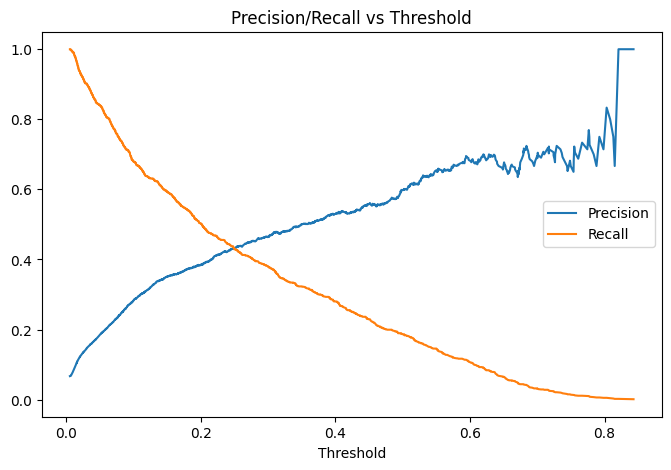

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision/Recall vs Threshold')
plt.show()
# график precision и recall от порога

In [ ]:
for i in [0.2,0.4,0.6,0.8]:
  y_pred_02 = (y_pred_proba >= i).astype(int)
  print(classification_report(y_val, y_pred_02))
  # Значения метрик от порога

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     13997
           1       0.39      0.50      0.44      1003

    accuracy                           0.91     15000
   macro avg       0.68      0.72      0.70     15000
weighted avg       0.92      0.91      0.92     15000

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     13997
           1       0.53      0.27      0.36      1003

    accuracy                           0.94     15000
   macro avg       0.74      0.63      0.66     15000
weighted avg       0.92      0.94      0.93     15000

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     13997
           1       0.67      0.10      0.17      1003

    accuracy                           0.94     15000
   macro avg       0.81      0.55      0.57     15000
weighted avg       0.92      0.94      0.91     15000

              preci

                                feature  importance
0  RevolvingUtilizationOfUnsecuredLines   33.862919
2  NumberOfTime30-59DaysPastDueNotWorse   14.605307
6               NumberOfTimes90DaysLate   13.156501
1                                   age    8.342607
8  NumberOfTime60-89DaysPastDueNotWorse    7.826486
5       NumberOfOpenCreditLinesAndLoans    7.437745
3                             DebtRatio    5.953794
7          NumberRealEstateLoansOrLines    4.925689
4                         MonthlyIncome    3.423808
9                    NumberOfDependents    0.465143


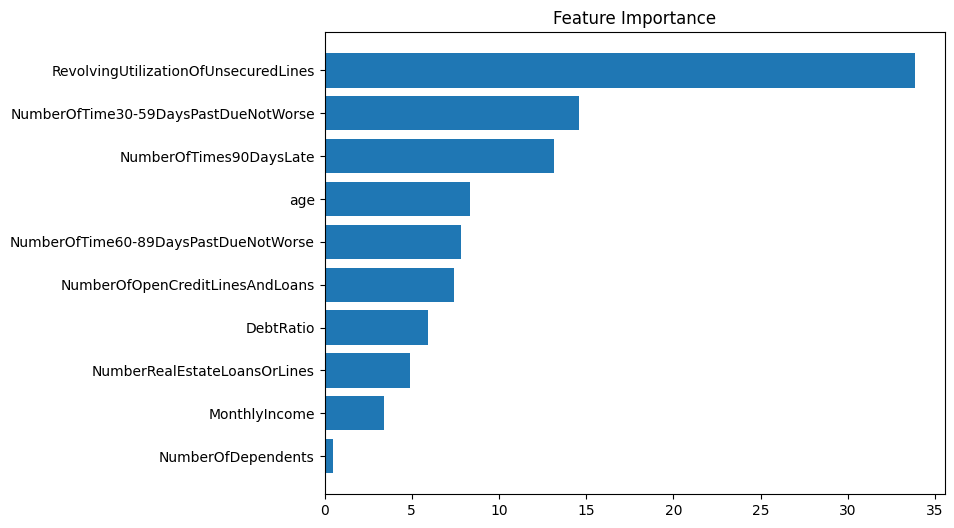

In [ ]:
importances = model.get_feature_importance()
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(8,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.show()
# важность признаков

# submission для кэгл

In [ ]:
dft = pd.read_csv('/content/drive/MyDrive/datasets/GiveMeSomeCredit-testing.csv',index_col=0)

In [ ]:
dft.index.name='id'

In [ ]:
dft['DebtRatio'] = dft['DebtRatio'].clip(upper=dft['DebtRatio'].quantile(0.975))
# ограничение значений до 5

In [ ]:
dft['MonthlyIncome']=dft['MonthlyIncome'].fillna(dft['MonthlyIncome'].median())
dft['NumberOfDependents']=dft['NumberOfDependents'].fillna(dft['NumberOfDependents'].median())

In [ ]:
cap = dft['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
dft['RevolvingUtilizationOfUnsecuredLines'] = dft['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap)

In [ ]:
for col in ['NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTime30-59DaysPastDueNotWorse']:
  median_val = dft.loc[~dft[col].isin([96,98]),col].median()
  dft[col]=dft[col].replace([96,98],median_val)

In [ ]:
dft = dft.drop(columns='SeriousDlqin2yrs')

In [ ]:
dft

In [ ]:
dft_proba = model.predict_proba(dft)[:,1]

In [ ]:
dft['Probability'] = dft_proba

In [ ]:
dft1 = dft['Probability']

In [ ]:
dft1

In [ ]:
dft1.to_csv('submission.csv')